In [1]:
# =========================================================
# 0. 기본 설정
# =========================================================

import os
import gc
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# 새로운 데이터 import
area = pd.read_csv('/content/drive/MyDrive/2026_기상청_축산/hanwoo_area.csv')

## [1] 중복 행 처리

In [85]:
area.head()

,FARM_UNIQUE_NO,C2023,C2024,C2025,AREA
0,X8bGdfHedF2o5xSAAERtEA==,23.0,26.0,25.0,220.00
1,N9t4B2mc+EZsH7wBLT8U4Q==,37.0,34.0,32.0,431.05
2,DeEu4RIkIUXq7NyTBwD8vg==,10.0,5.0,3.0,265.82
3,fgQkQJ+iyrFZDHsC9ih9mQ==,35.0,41.0,40.0,593.80
4,2mUAsXfTviEJtFBM7s31uw==,16.0,14.0,15.0,155.61


In [2]:
#########################
# 1. -99 결측 처리
#########################
area = area.replace([-99, -99.0], np.nan)

In [3]:
#########################
# 2. 완전 중복 행 확인 및 제거
#########################
print("원본 area shape:", area.shape)

exact_dup_count = area.duplicated().sum()
print("완전 중복 행 개수:", exact_dup_count)

area_no_exact_dup = area.drop_duplicates().copy()

print("완전 중복 제거 후 shape:", area_no_exact_dup.shape)
print("제거 후 완전 중복 행 개수:", area_no_exact_dup.duplicated().sum())

원본 area shape: (91896, 5)
완전 중복 행 개수: 16
완전 중복 제거 후 shape: (91880, 5)
제거 후 완전 중복 행 개수: 0


In [4]:
#########################
## 3. FARM_UNIQUE_NO 기준 중복 여부 확인
#########################
farm_dup_count = area_no_exact_dup.duplicated("FARM_UNIQUE_NO").sum()
farm_dup_farms = area_no_exact_dup.loc[
    area_no_exact_dup.duplicated("FARM_UNIQUE_NO", keep=False),
    "FARM_UNIQUE_NO"
].nunique()

print("FARM_UNIQUE_NO 기준 중복 행 수:", farm_dup_count)
print("중복된 FARM_UNIQUE_NO 개수:", farm_dup_farms)

FARM_UNIQUE_NO 기준 중복 행 수: 5177
중복된 FARM_UNIQUE_NO 개수: 4932


In [5]:
# 4. 중복된 FARM_UNIQUE_NO의 값이 어떻게 다른지 요약 - 정보 확인용
farm_dup_mask = area_no_exact_dup.duplicated("FARM_UNIQUE_NO", keep=False)

area_farm_dup = (
    area_no_exact_dup.loc[farm_dup_mask]
    .sort_values(["FARM_UNIQUE_NO"])
    .copy()
)

farm_dup_size = (
    area_farm_dup
    .groupby("FARM_UNIQUE_NO")
    .size()
    .reset_index(name="n_rows")
    .sort_values("n_rows", ascending=False)
)

check_cols = ["C2023", "C2024", "C2025", "AREA"]

farm_dup_summary = (
    area_farm_dup
    .groupby("FARM_UNIQUE_NO")
    .agg(
        n_rows=("FARM_UNIQUE_NO", "size"),
        C2023_values=("C2023", lambda x: sorted(x.dropna().unique().tolist())),
        C2024_values=("C2024", lambda x: sorted(x.dropna().unique().tolist())),
        C2025_values=("C2025", lambda x: sorted(x.dropna().unique().tolist())),
        AREA_values=("AREA", lambda x: sorted(x.dropna().unique().tolist())),
        C2023_sum=("C2023", "sum"),
        C2024_sum=("C2024", "sum"),
        C2025_sum=("C2025", "sum"),
        AREA_sum=("AREA", "sum"),
        AREA_max=("AREA", "max"),
        AREA_mean=("AREA", "mean")
    )
    .reset_index()
    .sort_values("n_rows", ascending=False)
)

display(farm_dup_summary.head(30))

,FARM_UNIQUE_NO,n_rows,C2023_values,C2024_values,C2025_values,AREA_values,C2023_sum,C2024_sum,C2025_sum,AREA_sum,AREA_max,AREA_mean
1060,BMMzHQjnluuhBtuoYfX5TA==,5,"[8.0, 9.0, 20.0, 21.0]","[5.0, 7.0, 12.0]","[1.0, 2.0]",[],67.0,29.0,3.0,0.00,NaN,NaN
4839,yii7R7asNxrQuPlkv8KoDw==,5,"[2.0, 6.0, 9.0, 83.0]","[2.0, 7.0, 10.0, 46.0]","[2.0, 3.0, 4.0, 19.0, 41.0]",[],102.0,67.0,69.0,0.00,NaN,NaN
2845,YNfzOD7l5M0mf4uZQJe2Xw==,4,"[112.0, 141.0, 168.0, 1519.0]","[111.0, 140.0, 167.0, 1509.0]","[112.0, 136.0, 167.0, 1452.0]",[],1940.0,1927.0,1867.0,0.00,NaN,NaN
1690,JEDK50KfOgQoXen/vqbyhg==,4,"[4.0, 7.0, 12.0, 41.0]","[2.0, 11.0, 13.0, 42.0]","[2.0, 3.0, 7.0, 67.0]",[],64.0,68.0,79.0,0.00,NaN,NaN
1588,ID2w+faYTF3MmboistgQIQ==,4,"[24.0, 68.0, 126.0, 167.0]","[36.0, 69.0, 133.0, 168.0]","[15.0, 85.0, 87.0, 91.0]",[4096.0],385.0,406.0,278.0,16384.00,4096.00,4096.00
265,1HNdLJKUhT03eBtxwJYfTg==,4,"[1.0, 9.0, 47.0, 50.0]","[2.0, 6.0, 59.0, 63.0]","[4.0, 30.0, 32.0, 69.0]",[],107.0,130.0,135.0,0.00,NaN,NaN
2929,ZWgX6da8p/yzelWwKmydOw==,4,"[2.0, 4.0, 7.0, 52.0]","[3.0, 5.0, 10.0, 48.0]","[3.0, 4.0, 10.0, 52.0]",[952.0],65.0,66.0,69.0,3808.00,952.00,952.00
4911,zcKIbGWvkaEsFrgeBDJQqw==,4,"[28.0, 29.0, 51.0, 134.0]",[252.0],[248.0],[297.0],242.0,252.0,248.0,1188.00,297.00,297.00
3721,jgrz+U0lzw1z0vpXJvnBPw==,4,"[2.0, 4.0, 13.0]","[2.0, 4.0, 5.0]","[1.0, 2.0, 5.0]",[],21.0,15.0,8.0,0.00,NaN,NaN
778,8+efejoxRpMuZqOlX6Hy3A==,4,"[8.0, 51.0, 105.0, 377.0]","[49.0, 102.0, 371.0]","[46.0, 102.0, 371.0]",[3762.22],541.0,522.0,519.0,15048.88,3762.22,3762.22


In [6]:
# ============================================================
# 5. 집계 전 최소 flag 생성
# ============================================================

area_no_exact_dup["scale_info_missing_row"] = (
    area_no_exact_dup[["C2023", "C2024", "C2025"]]
    .isna()
    .any(axis=1)
    .astype(int)
)

area_no_exact_dup["area_missing_row"] = (
    area_no_exact_dup["AREA"]
    .isna()
    .astype(int)
)

In [7]:
# ============================================================
# 6. FARM_UNIQUE_NO 기준 집계
# ============================================================

def sum_min_count(x):
    return x.sum(min_count=1)

area_farm_agg = (
    area_no_exact_dup
    .groupby("FARM_UNIQUE_NO", as_index=False)
    .agg(
        C2023=("C2023", sum_min_count),
        C2024=("C2024", sum_min_count),
        C2025=("C2025", sum_min_count),

        AREA_sum=("AREA", sum_min_count),
        AREA_max=("AREA", "max"),
        AREA_mean=("AREA", "mean"),

        n_area_rows=("FARM_UNIQUE_NO", "size"),
        n_area_nonmissing=("AREA", lambda x: x.notna().sum()),

        scale_info_missing=("scale_info_missing_row", "max"),
        area_missing_any_row=("area_missing_row", "max")
    )
)

print("집계 전 shape:", area_no_exact_dup.shape)
print("집계 후 shape:", area_farm_agg.shape)
print("집계 후 FARM_UNIQUE_NO 중복 개수:", area_farm_agg.duplicated("FARM_UNIQUE_NO").sum())

display(area_farm_agg.head())

집계 전 shape: (91880, 7)
집계 후 shape: (86703, 11)
집계 후 FARM_UNIQUE_NO 중복 개수: 0


,FARM_UNIQUE_NO,C2023,C2024,C2025,AREA_sum,AREA_max,AREA_mean,n_area_rows,n_area_nonmissing,scale_info_missing,area_missing_any_row
0,++3dDT9h9GLLBVoQDgn1IA==,69.0,55.0,37.0,1056.00,1056.00,1056.00,1,1,0,0
1,++9y4LAgYZMHjJNqlquqOA==,9.0,8.0,6.0,90.00,90.00,90.00,1,1,0,0
2,++BS1viAh3hOdGNLUqO9AQ==,8.0,NaN,NaN,NaN,NaN,NaN,1,0,1,1
3,++EgHgT0FBhXP2UY4tsA2Q==,126.0,132.0,134.0,1040.00,1040.00,1040.00,1,1,0,0
4,++FegxXsnx/IotYuAWBj8g==,6.0,9.0,6.0,368.34,368.34,368.34,1,1,0,0


In [8]:
# ============================================================
# 7. 최소 flag 정리
# ============================================================

# 같은 FARM_UNIQUE_NO 안에 여러 행이 있었는지
area_farm_agg["multi_area_row_flag"] = (
    area_farm_agg["n_area_rows"] > 1
).astype(int)

# 집계 후에도 AREA를 사용할 수 없는지
# 즉, 이후 AREA 결측 대체가 필요한지
area_farm_agg["area_missing"] = (
    area_farm_agg["AREA_max"].isna()
).astype(int)

# 사육두수 정보가 원래 불완전했는지
area_farm_agg["scale_info_missing"] = (
    area_farm_agg["scale_info_missing"] > 0
).astype(int)

display(
    area_farm_agg[
        [
            "FARM_UNIQUE_NO",
            "C2023", "C2024", "C2025",
            "AREA_sum", "AREA_max", "AREA_mean",
            "n_area_rows", "multi_area_row_flag",
            "area_missing", "scale_info_missing"
        ]
    ].head(20)
)

,FARM_UNIQUE_NO,C2023,C2024,C2025,AREA_sum,AREA_max,AREA_mean,n_area_rows,multi_area_row_flag,area_missing,scale_info_missing
0,++3dDT9h9GLLBVoQDgn1IA==,69.0,55.0,37.0,1056.00,1056.00,1056.00,1,0,0,0
1,++9y4LAgYZMHjJNqlquqOA==,9.0,8.0,6.0,90.00,90.00,90.00,1,0,0,0
2,++BS1viAh3hOdGNLUqO9AQ==,8.0,NaN,NaN,NaN,NaN,NaN,1,0,1,1
3,++EgHgT0FBhXP2UY4tsA2Q==,126.0,132.0,134.0,1040.00,1040.00,1040.00,1,0,0,0
4,++FegxXsnx/IotYuAWBj8g==,6.0,9.0,6.0,368.34,368.34,368.34,1,0,0,0
5,++IiEaoytjgI1NhMkDzS1Q==,4.0,30.0,22.0,190.00,190.00,190.00,1,0,0,0
6,++JGJuguC4RUqLsXvUOLmQ==,67.0,70.0,64.0,1852.00,1852.00,1852.00,1,0,0,0
7,++NG9blILlOmugj/ieu1gQ==,NaN,NaN,2.0,620.50,620.50,620.50,1,0,0,1
8,++RjpVT+dYlDXbsNj/zxTg==,49.0,45.0,54.0,14508.32,14508.32,14508.32,1,0,0,0
9,++Zcd9GYvIZuL4RS4a0/0w==,24.0,22.0,25.0,130.00,130.00,130.00,1,0,0,0


In [9]:
# ============================================================
# 8. 결측치 처리 전 최종 검증
# ============================================================

print("최종 area_farm_agg shape:", area_farm_agg.shape)
print("FARM_UNIQUE_NO 고유 개수:", area_farm_agg["FARM_UNIQUE_NO"].nunique())
print("FARM_UNIQUE_NO 중복 개수:", area_farm_agg.duplicated("FARM_UNIQUE_NO").sum())

assert area_farm_agg.duplicated("FARM_UNIQUE_NO").sum() == 0, \
    "아직 FARM_UNIQUE_NO 중복이 남아 있습니다."

print("\n집계 후 결측 개수:")
display(
    area_farm_agg[
        ["C2023", "C2024", "C2025", "AREA_sum", "AREA_max", "AREA_mean"]
    ].isna().sum()
)

print("\n최소 flag 분포:")
display(area_farm_agg[["multi_area_row_flag", "area_missing", "scale_info_missing"]].sum())

최종 area_farm_agg shape: (86703, 13)
FARM_UNIQUE_NO 고유 개수: 86703
FARM_UNIQUE_NO 중복 개수: 0

집계 후 결측 개수:


,0
C2023,3367
C2024,8754
C2025,13089
AREA_sum,27154
AREA_max,27154
AREA_mean,27154



최소 flag 분포:


,0
multi_area_row_flag,4932
area_missing,27154
scale_info_missing,19110


## [2] 결측치 패턴 확인



In [10]:
# ============================================================
# 1. 집계 후 데이터 기준 결측률 확인
# ============================================================

missing_summary = pd.DataFrame({
    "missing_count": area_farm_agg.isna().sum(),
    "missing_rate": area_farm_agg.isna().mean()
}).sort_values("missing_rate", ascending=False)

display(missing_summary)

,missing_count,missing_rate
AREA_sum,27154,0.313184
AREA_mean,27154,0.313184
AREA_max,27154,0.313184
C2025,13089,0.150964
C2024,8754,0.100965
C2023,3367,0.038834
FARM_UNIQUE_NO,0,0.000000
n_area_rows,0,0.000000
n_area_nonmissing,0,0.000000
scale_info_missing,0,0.000000


In [11]:
# ============================================================
# 2. 주요 변수 결측 패턴 확인
# ============================================================

c_cols = ["C2023", "C2024", "C2025"]
area_col = "AREA_max"   # 집계 후 AREA 대표값 기준

# C2023~C2025가 모두 결측인 농장 수
all_c_missing = area_farm_agg[c_cols].isna().all(axis=1).sum()

# AREA 결측 농장 수
area_missing = area_farm_agg[area_col].isna().sum()

# AREA 결측이면서 C2023~C2025도 모두 결측인 농장 수
area_and_all_c_missing = (
    area_farm_agg[area_col].isna()
    & area_farm_agg[c_cols].isna().all(axis=1)
).sum()

print("C2023~C2025 모두 결측:", all_c_missing)
print(f"{area_col} 결측:", area_missing)
print(f"{area_col} 결측이면서 C2023~C2025 모두 결측:", area_and_all_c_missing)

C2023~C2025 모두 결측: 0
AREA_max 결측: 27154
AREA_max 결측이면서 C2023~C2025 모두 결측: 0


In [12]:
# ============================================================
# 3. 결측 패턴 확인
# ============================================================

missing_pattern = (
    area_farm_agg[c_cols + [area_col]]
    .isna()
    .value_counts()
)

# ============================================================
# 4. 결측 패턴을 표 형태로 정리
# ============================================================

missing_pattern_df = (
    area_farm_agg[c_cols + [area_col]]
    .isna()
    .value_counts()
    .reset_index(name="count")
)

missing_pattern_df["%"] = (
    missing_pattern_df["count"] / len(area_farm_agg) * 100
)

display(missing_pattern_df)

,C2023,C2024,C2025,AREA_max,count,%
0,False,False,False,False,50371,58.096029
1,False,False,False,True,19531,22.526326
2,False,True,True,True,3598,4.149799
3,False,False,True,False,3502,4.039076
4,False,True,True,False,3349,3.862611
5,False,False,True,True,2378,2.742696
6,True,False,False,False,1120,1.291766
7,True,False,False,True,785,0.905390
8,True,True,False,False,699,0.806200
9,True,True,False,True,501,0.577835


*   C2023~C2025와 AREA_max가 모두 관측된 농장이 50,371개로 전체의 58.10%
*   C2023~C2025는 모두 있는데 AREA_max만 결측인 농장이 19,531개로 22.53%
* 또한 C2023만 있고 C2024, C2025, AREA_max가 결측인 패턴도 3,598개로 나타나므로, 최근 연도 사육두수 결측도 먼저 보간할 필요




In [13]:
# ============================================================
# 5. AREA 후보별 결측 비교
# ============================================================

area_candidate_cols = ["AREA_sum", "AREA_max", "AREA_mean"]

area_missing_compare = pd.DataFrame({
    "missing_count": area_farm_agg[area_candidate_cols].isna().sum(),
    "missing_rate": area_farm_agg[area_candidate_cols].isna().mean()
})

display(area_missing_compare)

# 세 AREA 후보의 결측 위치가 완전히 같은지 확인
same_missing_area = (
    area_farm_agg["AREA_sum"].isna().equals(area_farm_agg["AREA_max"].isna())
    and area_farm_agg["AREA_max"].isna().equals(area_farm_agg["AREA_mean"].isna())
)

print("AREA_sum, AREA_max, AREA_mean 결측 위치 동일 여부:", same_missing_area)

,missing_count,missing_rate
AREA_sum,27154,0.313184
AREA_max,27154,0.313184
AREA_mean,27154,0.313184


AREA_sum, AREA_max, AREA_mean 결측 위치 동일 여부: True


## [3] 결측치 처리

### 3-1. C2023~C2025 결측 처리
- 농장 내부 연도 보간 사용

In [14]:
# 근거 1 상관관계 확인
count_cols = ["C2023", "C2024", "C2025"]

# Pearson correlation
pearson_corr = area_farm_agg[count_cols].corr(method="pearson")

# Spearman correlation
spearman_corr = area_farm_agg[count_cols].corr(method="spearman")

print("Pearson correlation")
display(pearson_corr)

print("Spearman correlation")
display(spearman_corr)

Pearson correlation


,C2023,C2024,C2025
C2023,1.000000,0.955274,0.928501
C2024,0.955274,1.000000,0.959024
C2025,0.928501,0.959024,1.000000


Spearman correlation


,C2023,C2024,C2025
C2023,1.000000,0.939209,0.895980
C2024,0.939209,1.000000,0.940856
C2025,0.895980,0.940856,1.000000


C2023~C2025는 동일 농장의 연도별 사육두수이므로 인접 연도 간 연속성이 존재할 것으로 판단하였다. 실제로 연도별 사육두수 간 상관관계를 확인하여, 높은 양의 상관관계가 나타났으므로 농장 내부 연도 보간을 적용하였다.

In [16]:
# 근거 2 pairwise 관측 개수도 같이 확인
pairwise_n = pd.DataFrame(index=count_cols, columns=count_cols)

for c1 in count_cols:
    for c2 in count_cols:
        pairwise_n.loc[c1, c2] = area_farm_agg[[c1, c2]].dropna().shape[0]

print("Pairwise non-missing counts")
display(pairwise_n)

Pairwise non-missing counts


,C2023,C2024,C2025
C2023,83336,75782,70509
C2024,75782,77949,71807
C2025,70509,71807,73614


In [17]:
# 근거 3 연도별 변화량 분포 확인
tmp = area_farm_agg[count_cols].copy()

tmp["diff_24_23"] = tmp["C2024"] - tmp["C2023"]
tmp["diff_25_24"] = tmp["C2025"] - tmp["C2024"]
tmp["diff_25_23"] = tmp["C2025"] - tmp["C2023"]

diff_cols = ["diff_24_23", "diff_25_24", "diff_25_23"]

display(tmp[diff_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

,diff_24_23,diff_25_24,diff_25_23
count,75782.000000,71807.000000,70509.000000
mean,-1.749479,-1.421407,-3.157881
std,18.988333,18.297231,24.459917
min,-648.000000,-700.000000,-720.000000
1%,-59.000000,-53.000000,-79.000000
5%,-22.000000,-21.000000,-32.000000
25%,-5.000000,-4.000000,-8.000000
50%,-1.000000,-1.000000,-2.000000
75%,2.000000,2.000000,3.000000
95%,16.000000,16.000000,23.000000


In [18]:
tmp["growth_24_23"] = tmp["diff_24_23"] / tmp["C2023"].replace(0, np.nan)
tmp["growth_25_24"] = tmp["diff_25_24"] / tmp["C2024"].replace(0, np.nan)
tmp["growth_25_23"] = tmp["diff_25_23"] / tmp["C2023"].replace(0, np.nan)

growth_cols = ["growth_24_23", "growth_25_24", "growth_25_23"]

display(
    tmp[growth_cols]
    .replace([np.inf, -np.inf], np.nan)
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
)

,growth_24_23,growth_25_24,growth_25_23
count,75782.000000,71807.000000,70509.000000
mean,0.041110,0.054945,0.053300
std,2.056914,1.843587,2.528557
min,-0.994652,-0.995781,-0.997872
1%,-0.850000,-0.854136,-0.913043
5%,-0.600000,-0.592593,-0.724438
25%,-0.211538,-0.200000,-0.313725
50%,-0.024390,-0.010638,-0.076923
75%,0.111111,0.108696,0.120690
95%,0.600000,0.600000,0.850000


연도 간 변화량의 중앙값이 크지 않고, 대부분의 농장이 전년도와 유사한 사육규모를 유지한다면, 결측 연도 값을 같은 농장의 인접 연도 값으로 보간하는 것이 전체 중앙값 대체보다 타당하다.

In [15]:
# 결측 처리
count_cols = ["C2023", "C2024", "C2025"]

area_imp = area_farm_agg.copy()

area_imp[["C2023_imp", "C2024_imp", "C2025_imp"]] = (
    area_imp[count_cols]
    .interpolate(axis=1, limit_direction="both")
)

# 사육두수는 count 성격이므로 반올림
for col in ["C2023_imp", "C2024_imp", "C2025_imp"]:
    area_imp[col] = area_imp[col].round().clip(lower=0)

### 3-2. 사육규모 파생변수 생성

In [16]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score

def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denom != 0
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100

def mape_safe(y_true, y_pred):
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# Fix: The 'squared' argument in mean_squared_error might not be supported in older scikit-learn versions.
# Calculating RMSE by taking the square root of MSE.
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MedAE": median_absolute_error(y_true, y_pred),
        "MAPE(%)": mape_safe(y_true, y_pred),
        "sMAPE(%)": smape(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

# ============================================================
# 1. 사육규모 파생변수 생성
# ============================================================

imp_count_cols = ["C2023_imp", "C2024_imp", "C2025_imp"]

area_imp["scale_avg"] = area_imp[imp_count_cols].mean(axis=1)
area_imp["scale_max"] = area_imp[imp_count_cols].max(axis=1)
area_imp["scale_min"] = area_imp[imp_count_cols].min(axis=1)
area_imp["scale_std"] = area_imp[imp_count_cols].std(axis=1)
area_imp["scale_range"] = area_imp["scale_max"] - area_imp["scale_min"]

area_imp["scale_change_23_25"] = (
    area_imp["C2025_imp"] - area_imp["C2023_imp"]
)

area_imp["scale_growth_23_25"] = (
    area_imp["scale_change_23_25"]
    / area_imp["C2023_imp"].replace(0, np.nan)
)

area_imp["scale_growth_23_25"] = (
    area_imp["scale_growth_23_25"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

# AREA 기준값: 우선 AREA_max를 target으로 사용
area_imp["AREA_base"] = area_imp["AREA_max"]

print("AREA_base 결측 수:", area_imp["AREA_base"].isna().sum())
print("AREA_base 관측 수:", area_imp["AREA_base"].notna().sum())

display(
    area_imp[
        [
            "C2023_imp", "C2024_imp", "C2025_imp",
            "scale_avg", "scale_max", "scale_min", "scale_std",
            "scale_range", "scale_change_23_25", "scale_growth_23_25",
            "AREA_base"
        ]
    ].head()
)


AREA_base 결측 수: 27154
AREA_base 관측 수: 59549


,C2023_imp,C2024_imp,C2025_imp,scale_avg,scale_max,scale_min,scale_std,scale_range,scale_change_23_25,scale_growth_23_25,AREA_base
0,69.0,55.0,37.0,53.666667,69.0,37.0,16.041613,32.0,-32.0,-0.463768,1056.00
1,9.0,8.0,6.0,7.666667,9.0,6.0,1.527525,3.0,-3.0,-0.333333,90.00
2,8.0,8.0,8.0,8.000000,8.0,8.0,0.000000,0.0,0.0,0.000000,NaN
3,126.0,132.0,134.0,130.666667,134.0,126.0,4.163332,8.0,8.0,0.063492,1040.00
4,6.0,9.0,6.0,7.000000,9.0,6.0,1.732051,3.0,0.0,0.000000,368.34


### 3-3. AREA 결측 처리 - 모델 비교1

In [17]:
## 어떤 모형이 가장 좋을지 비교 모델 구성하기

# ============================================================
# 2. AREA imputation 모델용 feature 설정
# ============================================================

area_model_features = [
    "C2023_imp", "C2024_imp", "C2025_imp",
    "scale_avg", "scale_max", "scale_min", "scale_std",
    "scale_range", "scale_change_23_25", "scale_growth_23_25",
    "n_area_rows", "multi_area_row_flag", "scale_info_missing"
]

target_col = "AREA_base"

# AREA가 관측된 농장만 validation 비교에 사용
model_df = area_imp[area_imp[target_col].notna()].copy()

# AREA가 0 이하인 값이 있으면 log1p target에서 문제가 될 수 있으므로 확인
print("AREA_base <= 0 개수:", (model_df[target_col] <= 0).sum())

# 음수나 0이 있으면 제거하거나 작은 값으로 보정
# 여기서는 0 이상만 사용
model_df = model_df[model_df[target_col] >= 0].copy()

X = model_df[area_model_features].copy()
y = model_df[target_col].copy()

print("모델 비교용 데이터 shape:", model_df.shape)
print("X shape:", X.shape)
print("y 결측 수:", y.isna().sum())

display(X.head())

AREA_base <= 0 개수: 4
모델 비교용 데이터 shape: (59549, 24)
X shape: (59549, 13)
y 결측 수: 0


,C2023_imp,C2024_imp,C2025_imp,scale_avg,scale_max,scale_min,scale_std,scale_range,scale_change_23_25,scale_growth_23_25,n_area_rows,multi_area_row_flag,scale_info_missing
0,69.0,55.0,37.0,53.666667,69.0,37.0,16.041613,32.0,-32.0,-0.463768,1,0,0
1,9.0,8.0,6.0,7.666667,9.0,6.0,1.527525,3.0,-3.0,-0.333333,1,0,0
3,126.0,132.0,134.0,130.666667,134.0,126.0,4.163332,8.0,8.0,0.063492,1,0,0
4,6.0,9.0,6.0,7.000000,9.0,6.0,1.732051,3.0,0.0,0.000000,1,0,0
5,4.0,30.0,22.0,18.666667,30.0,4.0,13.316656,26.0,18.0,4.500000,1,0,0


In [18]:
# ============================================================
# 3. 평가 함수 정의
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score

def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denom != 0
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100

def mape_safe(y_true, y_pred):
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred, squared=False),
        "MedAE": median_absolute_error(y_true, y_pred),
        "MAPE(%)": mape_safe(y_true, y_pred),
        "sMAPE(%)": smape(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score

# Redefining custom metrics and regression_metrics to fix 'squared' argument issue
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denom != 0
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100

def mape_safe(y_true, y_pred):
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)), # Fixed: calculate RMSE by taking square root of MSE
        "MedAE": median_absolute_error(y_true, y_pred),
        "MAPE(%)": mape_safe(y_true, y_pred),
        "sMAPE(%)": smape(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

# ============================================================
# 4. KNN / Linear / Ridge / Lasso / RF / XGBoost / LightGBM 비교
# ============================================================

results = []

# ------------------------------------------------------------
# train / validation split
# ------------------------------------------------------------

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# log target
y_train_log = np.log1p(y_train)
y_valid_true = y_valid.values

# ------------------------------------------------------------
# 0. Median baseline
# ------------------------------------------------------------

median_pred = np.full_like(y_valid_true, fill_value=y_train.median(), dtype=float)
metrics = regression_metrics(y_valid_true, median_pred)
metrics["method"] = "median_baseline"
results.append(metrics)

# ------------------------------------------------------------
# 1. KNN Imputation 방식
#    - X feature로 가까운 농장을 찾고, AREA_log를 impute
# ------------------------------------------------------------

scaler_knn = StandardScaler()

X_train_scaled = scaler_knn.fit_transform(X_train)
X_valid_scaled = scaler_knn.transform(X_valid)

# train matrix: [scaled features + observed log AREA]
train_matrix = np.column_stack([X_train_scaled, y_train_log.values])

# valid matrix: [scaled features + missing AREA]
valid_matrix = np.column_stack([
    X_valid_scaled,
    np.full(shape=(len(X_valid_scaled),), fill_value=np.nan)
])

knn_imputer = KNNImputer(
    n_neighbors=5,
    weights="distance"
)

knn_imputer.fit(train_matrix)
valid_imputed_matrix = knn_imputer.transform(valid_matrix)

knn_pred_log = valid_imputed_matrix[:, -1]
knn_pred = np.expm1(knn_pred_log)
knn_pred = np.clip(knn_pred, a_min=0, a_max=None)

metrics = regression_metrics(y_valid_true, knn_pred)
metrics["method"] = "knn_imputer"
results.append(metrics)

# ------------------------------------------------------------
# 2. Linear / Ridge / Lasso
# ------------------------------------------------------------

linear_models = {
    "linear_regression": LinearRegression(),
    "ridge": Ridge(alpha=1.0, random_state=42),
    "lasso": Lasso(alpha=0.001, random_state=42, max_iter=10000)
}

for name, model in linear_models.items():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipe.fit(X_train, y_train_log)
    pred_log = pipe.predict(X_valid)
    pred = np.expm1(pred_log)
    pred = np.clip(pred, a_min=0, a_max=None)

    metrics = regression_metrics(y_valid_true, pred)
    metrics["method"] = name
    results.append(metrics)

# ------------------------------------------------------------
# 3. RandomForest
# ------------------------------------------------------------

rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train_log)
rf_pred_log = rf_pipe.predict(X_valid)
rf_pred = np.expm1(rf_pred_log)
rf_pred = np.clip(rf_pred, a_min=0, a_max=None)

metrics = regression_metrics(y_valid_true, rf_pred)
metrics["method"] = "random_forest"
results.append(metrics)

# ------------------------------------------------------------
# 4. XGBoost
# ------------------------------------------------------------

try:
    from xgboost import XGBRegressor

    xgb_model = XGBRegressor(
        n_estimators=600,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    xgb_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", xgb_model)
    ])

    xgb_pipe.fit(X_train, y_train_log)
    xgb_pred_log = xgb_pipe.predict(X_valid)
    xgb_pred = np.expm1(xgb_pred_log)
    xgb_pred = np.clip(xgb_pred, a_min=0, a_max=None)

    metrics = regression_metrics(y_valid_true, xgb_pred)
    metrics["method"] = "xgboost"
    results.append(metrics)

except ImportError:
    print("xgboost가 설치되어 있지 않습니다. 필요하면: !pip install xgboost")

# ------------------------------------------------------------
# 5. LightGBM
# ------------------------------------------------------------

try:
    from lightgbm import LGBMRegressor

    lgbm_model = LGBMRegressor(
        n_estimators=600,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="regression",
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    lgbm_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", lgbm_model)
    ])

    lgbm_pipe.fit(X_train, y_train_log)
    lgbm_pred_log = lgbm_pipe.predict(X_valid)
    lgbm_pred = np.expm1(lgbm_pred_log)
    lgbm_pred = np.clip(lgbm_pred, a_min=0, a_max=None)

    metrics = regression_metrics(y_valid_true, lgbm_pred)
    metrics["method"] = "lightgbm"
    results.append(metrics)

except ImportError:
    print("lightgbm이 설치되어 있지 않습니다. 필요하면: !pip install lightgbm")

# ------------------------------------------------------------
# 결과 정리
# ------------------------------------------------------------

result_df = pd.DataFrame(results)

cols = ["method", "MAE", "RMSE", "MedAE", "MAPE(%)", "sMAPE(%)", "R2"]
result_df = result_df[cols].sort_values("RMSE").reset_index(drop=True)

display(result_df)

,method,MAE,RMSE,MedAE,MAPE(%),sMAPE(%),R2
0,xgboost,319.611928,7.429616e+02,157.617268,67.451863,50.728757,3.848556e-01
1,lightgbm,320.639281,7.450462e+02,156.841452,67.686984,50.870194,3.813989e-01
2,random_forest,321.896816,7.470789e+02,159.402563,67.977686,51.002768,3.780188e-01
3,knn_imputer,368.956478,7.930393e+02,198.956044,92.144736,57.168205,2.991361e-01
4,median_baseline,515.801748,9.872108e+02,310.100000,171.059757,77.043395,-8.608560e-02
5,lasso,558111.339325,6.070288e+07,195.752480,2785.411837,60.614945,-4.106415e+09
6,ridge,852456.336542,9.283618e+07,195.694897,4194.390300,60.602846,-9.604589e+09
7,linear_regression,853983.504317,9.300313e+07,195.694489,4201.690767,60.602662,-9.639166e+09


In [24]:
# ============================================================
# 5. Median baseline 대비 개선율
# ============================================================

baseline_rmse = result_df.loc[result_df["method"] == "median_baseline", "RMSE"].iloc[0]
baseline_mae = result_df.loc[result_df["method"] == "median_baseline", "MAE"].iloc[0]

result_df["RMSE_improvement_vs_median(%)"] = (
    (baseline_rmse - result_df["RMSE"]) / baseline_rmse * 100
)

result_df["MAE_improvement_vs_median(%)"] = (
    (baseline_mae - result_df["MAE"]) / baseline_mae * 100
)

result_df = result_df.sort_values("RMSE").reset_index(drop=True)

display(result_df)

,method,MAE,RMSE,MedAE,MAPE(%),sMAPE(%),R2,RMSE_improvement_vs_median(%),MAE_improvement_vs_median(%)
0,xgboost,319.611928,7.429616e+02,157.617268,67.451863,50.728757,3.848556e-01,2.474134e+01,38.035897
1,lightgbm,320.639281,7.450462e+02,156.841452,67.686984,50.870194,3.813989e-01,2.453018e+01,37.836721
2,random_forest,321.896816,7.470789e+02,159.402563,67.977686,51.002768,3.780188e-01,2.432427e+01,37.592919
3,knn_imputer,368.956478,7.930393e+02,198.956044,92.144736,57.168205,2.991361e-01,1.966870e+01,28.469324
4,median_baseline,515.801748,9.872108e+02,310.100000,171.059757,77.043395,-8.608560e-02,0.000000e+00,0.000000
5,lasso,558111.339325,6.070288e+07,195.752480,2785.411837,60.614945,-4.106415e+09,-6.148828e+06,-108102.684727
6,ridge,852456.336542,9.283618e+07,195.694897,4194.390300,60.602846,-9.604589e+09,-9.403786e+06,-165168.213934
7,linear_regression,853983.504317,9.300313e+07,195.694489,4201.690767,60.602662,-9.639166e+09,-9.420698e+06,-165464.290436


In [ ]:
# ============================================================
# 6. 반복 split 평가 함수
# ============================================================

def compare_area_imputation_models(X, y, seeds=[42, 100, 2024, 2025, 777]):
    all_results = []

    for seed in seeds:
        X_train, X_valid, y_train, y_valid = train_test_split(
            X, y,
            test_size=0.2,
            random_state=seed
        )

        y_train_log = np.log1p(y_train)
        y_valid_true = y_valid.values

        # Median baseline
        median_pred = np.full_like(y_valid_true, fill_value=y_train.median(), dtype=float)
        metrics = regression_metrics(y_valid_true, median_pred)
        metrics["method"] = "median_baseline"
        metrics["seed"] = seed
        all_results.append(metrics)

        # KNN
        scaler_knn = StandardScaler()
        X_train_scaled = scaler_knn.fit_transform(X_train)
        X_valid_scaled = scaler_knn.transform(X_valid)

        train_matrix = np.column_stack([X_train_scaled, y_train_log.values])
        valid_matrix = np.column_stack([
            X_valid_scaled,
            np.full(shape=(len(X_valid_scaled),), fill_value=np.nan)
        ])

        knn_imputer = KNNImputer(n_neighbors=5, weights="distance")
        knn_imputer.fit(train_matrix)

        valid_imputed_matrix = knn_imputer.transform(valid_matrix)
        pred_log = valid_imputed_matrix[:, -1]
        pred = np.expm1(pred_log)
        pred = np.clip(pred, a_min=0, a_max=None)

        metrics = regression_metrics(y_valid_true, pred)
        metrics["method"] = "knn_imputer"
        metrics["seed"] = seed
        all_results.append(metrics)

        # Linear models
        linear_models = {
            "linear_regression": LinearRegression(),
            "ridge": Ridge(alpha=1.0, random_state=seed),
            "lasso": Lasso(alpha=0.001, random_state=seed, max_iter=10000)
        }

        for name, model in linear_models.items():
            pipe = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", model)
            ])

            pipe.fit(X_train, y_train_log)
            pred_log = pipe.predict(X_valid)
            pred = np.expm1(pred_log)
            pred = np.clip(pred, a_min=0, a_max=None)

            metrics = regression_metrics(y_valid_true, pred)
            metrics["method"] = name
            metrics["seed"] = seed
            all_results.append(metrics)

        # RandomForest
        rf_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(
                n_estimators=300,
                max_depth=12,
                min_samples_leaf=5,
                random_state=seed,
                n_jobs=-1
            ))
        ])

        rf_pipe.fit(X_train, y_train_log)
        pred_log = rf_pipe.predict(X_valid)
        pred = np.expm1(pred_log)
        pred = np.clip(pred, a_min=0, a_max=None)

        metrics = regression_metrics(y_valid_true, pred)
        metrics["method"] = "random_forest"
        metrics["seed"] = seed
        all_results.append(metrics)

        # XGBoost
        try:
            from xgboost import XGBRegressor

            xgb_pipe = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", XGBRegressor(
                    n_estimators=600,
                    learning_rate=0.03,
                    max_depth=5,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    objective="reg:squarederror",
                    random_state=seed,
                    n_jobs=-1
                ))
            ])

            xgb_pipe.fit(X_train, y_train_log)
            pred_log = xgb_pipe.predict(X_valid)
            pred = np.expm1(pred_log)
            pred = np.clip(pred, a_min=0, a_max=None)

            metrics = regression_metrics(y_valid_true, pred)
            metrics["method"] = "xgboost"
            metrics["seed"] = seed
            all_results.append(metrics)

        except ImportError:
            pass

        # LightGBM
        try:
            from lightgbm import LGBMRegressor

            lgbm_pipe = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", LGBMRegressor(
                    n_estimators=600,
                    learning_rate=0.03,
                    num_leaves=31,
                    max_depth=-1,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    objective="regression",
                    random_state=seed,
                    n_jobs=-1,
                    verbose=-1
                ))
            ])

            lgbm_pipe.fit(X_train, y_train_log)
            pred_log = lgbm_pipe.predict(X_valid)
            pred = np.expm1(pred_log)
            pred = np.clip(pred, a_min=0, a_max=None)

            metrics = regression_metrics(y_valid_true, pred)
            metrics["method"] = "lightgbm"
            metrics["seed"] = seed
            all_results.append(metrics)

        except ImportError:
            pass

    all_result_df = pd.DataFrame(all_results)

    summary_df = (
        all_result_df
        .groupby("method")
        .agg(
            MAE_mean=("MAE", "mean"),
            MAE_std=("MAE", "std"),
            RMSE_mean=("RMSE", "mean"),
            RMSE_std=("RMSE", "std"),
            MedAE_mean=("MedAE", "mean"),
            MAPE_mean=("MAPE(%)", "mean"),
            sMAPE_mean=("sMAPE(%)", "mean"),
            R2_mean=("R2", "mean")
        )
        .reset_index()
        .sort_values("RMSE_mean")
    )

    return all_result_df, summary_df


all_result_df, summary_df = compare_area_imputation_models(X, y)

display(all_result_df.sort_values(["seed", "RMSE"]).head(30))
display(summary_df)

,MAE,RMSE,MedAE,MAPE(%),sMAPE(%),R2,method,seed
6,3.196119e+02,7.429616e+02,157.617268,67.451863,50.728757,3.848556e-01,xgboost,42
7,3.206393e+02,7.450462e+02,156.841452,67.686984,50.870194,3.813989e-01,lightgbm,42
5,3.218968e+02,7.470789e+02,159.402563,67.977686,51.002768,3.780188e-01,random_forest,42
1,3.689565e+02,7.930393e+02,198.956044,92.144736,57.168205,2.991361e-01,knn_imputer,42
0,5.158017e+02,9.872108e+02,310.100000,171.059757,77.043395,-8.608560e-02,median_baseline,42
4,5.581113e+05,6.070288e+07,195.752480,2785.411837,60.614945,-4.106415e+09,lasso,42
3,8.524563e+05,9.283618e+07,195.694897,4194.390300,60.602846,-9.604589e+09,ridge,42
2,8.539835e+05,9.300313e+07,195.694489,4201.690767,60.602662,-9.639166e+09,linear_regression,42
14,3.246645e+02,6.513227e+02,160.515982,66.580324,50.979967,4.369019e-01,xgboost,100
15,3.245010e+02,6.513577e+02,159.297773,66.447615,50.997306,4.368414e-01,lightgbm,100


,method,MAE_mean,MAE_std,RMSE_mean,RMSE_std,MedAE_mean,MAPE_mean,sMAPE_mean,R2_mean
2,lightgbm,3.277259e+02,5.593323e+00,7.530918e+02,6.187881e+01,159.601356,68.870531,51.132176,3.856185e-01
5,random_forest,3.289750e+02,5.389119e+00,7.543906e+02,5.955557e+01,160.990354,69.359981,51.294116,3.833744e-01
7,xgboost,3.277938e+02,6.099414e+00,7.549147e+02,6.350923e+01,159.626611,68.957026,51.069351,3.827391e-01
0,knn_imputer,3.735760e+02,7.885144e+00,7.924805e+02,5.982219e+01,198.848235,92.923142,56.984080,3.193980e-01
4,median_baseline,5.235936e+02,7.648177e+00,1.002892e+03,5.451304e+01,309.044000,169.313145,76.944971,-9.185615e-02
1,lasso,1.160772e+06,2.249618e+06,1.263655e+08,2.454846e+08,194.855201,5690.724028,60.533389,-8.502840e+10
6,ridge,1.847497e+06,3.621269e+06,2.013130e+08,3.951842e+08,194.736932,8981.699056,60.534772,-2.192601e+11
3,linear_regression,1.853111e+06,3.632915e+06,2.019258e+08,3.964554e+08,194.751618,9008.613211,60.534869,-2.206553e+11


### 3-4. 모델 비교2


모델 1: LightGBM_raw
- target = AREA_base
- 원 단위 AREA를 직접 예측

모델 2: LightGBM_log1p
- target = np.log1p(AREA_base)
- 예측 후 np.expm1()로 AREA 단위 복원

In [25]:
## import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score

from lightgbm import LGBMRegressor

In [28]:
# ============================================================
# 1. 데이터 준비
# ============================================================

# AREA 기준값
# 이미 AREA_base가 있으면 그대로 사용
# 없으면 AREA_max 기준으로 생성
if "AREA_base" not in area_imp.columns:
    area_imp["AREA_base"] = area_imp["AREA_max"]

# LightGBM feature
area_model_features = [
    "C2023_imp", "C2024_imp", "C2025_imp",
    "scale_avg", "scale_max", "scale_min", "scale_std",
    "scale_range", "scale_change_23_25", "scale_growth_23_25",
    "n_area_rows", "multi_area_row_flag", "scale_info_missing"
]

# AREA 관측값만 평가에 사용
model_df = area_imp[area_imp["AREA_base"].notna()].copy()

# AREA가 음수인 경우 제외
model_df = model_df[model_df["AREA_base"] >= 0].copy()

X = model_df[area_model_features].copy()
y = model_df["AREA_base"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("AREA target summary")
display(y.describe())

X shape: (59549, 13)
y shape: (59549,)
AREA target summary


,AREA_base
count,59549.000000
mean,743.447118
std,921.933095
min,0.000000
25%,210.000000
50%,452.000000
75%,967.710000
max,48360.000000


In [29]:
# ============================================================
# 2. 평가 함수
# ============================================================

def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denom != 0

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100


def mape_safe(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mask = y_true != 0

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MedAE": median_absolute_error(y_true, y_pred),
        "MAPE(%)": mape_safe(y_true, y_pred),
        "sMAPE(%)": smape(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

In [30]:
# ============================================================
# 3. LightGBM raw target vs log1p target 비교
# ============================================================

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

results = []

# ------------------------------------------------------------
# Model 1. LightGBM raw target
# ------------------------------------------------------------

lgbm_raw = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LGBMRegressor(
        n_estimators=600,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="regression",
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

lgbm_raw.fit(X_train, y_train)

pred_raw = lgbm_raw.predict(X_valid)
pred_raw = np.clip(pred_raw, a_min=0, a_max=None)

metrics_raw = regression_metrics(y_valid, pred_raw)
metrics_raw["method"] = "lightgbm_raw_target"
results.append(metrics_raw)


# ------------------------------------------------------------
# Model 2. LightGBM log1p target
# ------------------------------------------------------------

lgbm_log = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LGBMRegressor(
        n_estimators=600,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="regression",
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

y_train_log = np.log1p(y_train)

lgbm_log.fit(X_train, y_train_log)

pred_log = lgbm_log.predict(X_valid)
pred_log_back = np.expm1(pred_log)
pred_log_back = np.clip(pred_log_back, a_min=0, a_max=None)

metrics_log = regression_metrics(y_valid, pred_log_back)
metrics_log["method"] = "lightgbm_log1p_target"
results.append(metrics_log)


# ------------------------------------------------------------
# 결과 정리
# ------------------------------------------------------------

compare_lgbm_df = pd.DataFrame(results)

compare_lgbm_df = compare_lgbm_df[
    ["method", "MAE", "RMSE", "MedAE", "MAPE(%)", "sMAPE(%)", "R2"]
].sort_values("RMSE").reset_index(drop=True)

display(compare_lgbm_df)

,method,MAE,RMSE,MedAE,MAPE(%),sMAPE(%),R2
0,lightgbm_raw_target,355.496564,740.045099,229.031942,131.222910,57.911106,0.389676
1,lightgbm_log1p_target,320.639281,745.046157,156.841452,67.686984,50.870194,0.381399


In [81]:
# ============================================================
# 4. 반복 split으로 안정성 비교
# ============================================================

def compare_lgbm_raw_vs_log(X, y, seeds=[42, 100, 2024, 2025, 777]):
    all_results = []

    for seed in seeds:
        X_train, X_valid, y_train, y_valid = train_test_split(
            X,
            y,
            test_size=0.2,
            random_state=seed
        )

        # -------------------------------
        # raw target LightGBM
        # -------------------------------
        lgbm_raw = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", LGBMRegressor(
                n_estimators=600,
                learning_rate=0.03,
                num_leaves=31,
                max_depth=-1,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="regression",
                random_state=seed,
                n_jobs=-1,
                verbose=-1
            ))
        ])

        lgbm_raw.fit(X_train, y_train)

        pred_raw = lgbm_raw.predict(X_valid)
        pred_raw = np.clip(pred_raw, a_min=0, a_max=None)

        metrics = regression_metrics(y_valid, pred_raw)
        metrics["method"] = "lightgbm_raw_target"
        metrics["seed"] = seed
        all_results.append(metrics)

        # -------------------------------
        # log1p target LightGBM
        # -------------------------------
        lgbm_log = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", LGBMRegressor(
                n_estimators=600,
                learning_rate=0.03,
                num_leaves=31,
                max_depth=-1,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="regression",
                random_state=seed,
                n_jobs=-1,
                verbose=-1
            ))
        ])

        y_train_log = np.log1p(y_train)

        lgbm_log.fit(X_train, y_train_log)

        pred_log = lgbm_log.predict(X_valid)
        pred_log_back = np.expm1(pred_log)
        pred_log_back = np.clip(pred_log_back, a_min=0, a_max=None)

        metrics = regression_metrics(y_valid, pred_log_back)
        metrics["method"] = "lightgbm_log1p_target"
        metrics["seed"] = seed
        all_results.append(metrics)

    all_result_df = pd.DataFrame(all_results)

    summary_df = (
        all_result_df
        .groupby("method")
        .agg(
            MAE_mean=("MAE", "mean"),
            MAE_std=("MAE", "std"),
            RMSE_mean=("RMSE", "mean"),
            RMSE_std=("RMSE", "std"),
            MedAE_mean=("MedAE", "mean"),
            MAPE_mean=("MAPE(%)", "mean"),
            sMAPE_mean=("sMAPE(%)", "mean"),
            R2_mean=("R2", "mean")
        )
        .reset_index()
        .sort_values("RMSE_mean")
    )

    return all_result_df, summary_df


lgbm_all_result_df, lgbm_summary_df = compare_lgbm_raw_vs_log(X, y)

display(lgbm_all_result_df.sort_values(["seed", "RMSE"]))
display(lgbm_summary_df)

,MAE,RMSE,MedAE,MAPE(%),sMAPE(%),R2,method,seed
0,355.496564,740.045099,229.031942,131.222910,57.911106,0.389676,lightgbm_raw_target,42
1,320.639281,745.046157,156.841452,67.686984,50.870194,0.381399,lightgbm_log1p_target,42
2,357.841504,643.010745,230.626348,127.030282,57.700896,0.451182,lightgbm_raw_target,100
3,324.500957,651.357741,159.297773,66.447615,50.997306,0.436841,lightgbm_log1p_target,100
8,363.917104,757.390451,229.533731,131.350765,57.931348,0.410139,lightgbm_raw_target,777
9,331.502548,766.834953,161.879311,69.029115,51.297145,0.395336,lightgbm_log1p_target,777
4,367.621417,799.535586,226.450611,133.094141,57.743750,0.368853,lightgbm_raw_target,2024
5,334.795008,808.217283,156.630110,70.906148,51.238590,0.355072,lightgbm_log1p_target,2024
6,363.434216,788.039395,232.676128,135.066785,57.907414,0.369030,lightgbm_raw_target,2025
7,327.191803,794.002709,163.358136,70.282794,51.257647,0.359444,lightgbm_log1p_target,2025


,method,MAE_mean,MAE_std,RMSE_mean,RMSE_std,MedAE_mean,MAPE_mean,sMAPE_mean,R2_mean
1,lightgbm_raw_target,361.662161,4.907894,745.604255,62.057587,229.663752,131.552976,57.838903,0.397776
0,lightgbm_log1p_target,327.725919,5.593323,753.091769,61.878807,159.601356,68.870531,51.132176,0.385619


In [31]:
# ============================================================
# 5. 단일 split 기준 예측 분포 비교
# ============================================================

pred_compare_df = pd.DataFrame({
    "y_true": y_valid.values,
    "pred_raw": pred_raw,
    "pred_log1p": pred_log_back
})

display(
    pred_compare_df[
        ["y_true", "pred_raw", "pred_log1p"]
    ].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99])
)

,y_true,pred_raw,pred_log1p
count,11910.000000,11910.000000,11910.000000
mean,732.374915,740.453785,605.087319
std,947.318645,622.159935,592.803738
min,0.000000,192.880700,62.710816
1%,25.000000,212.768626,95.179288
5%,49.845000,249.338325,116.411878
25%,207.372500,366.194173,215.877057
50%,449.010000,551.035722,426.505480
75%,960.000000,908.284923,781.280343
90%,1660.284000,1364.049205,1247.935233


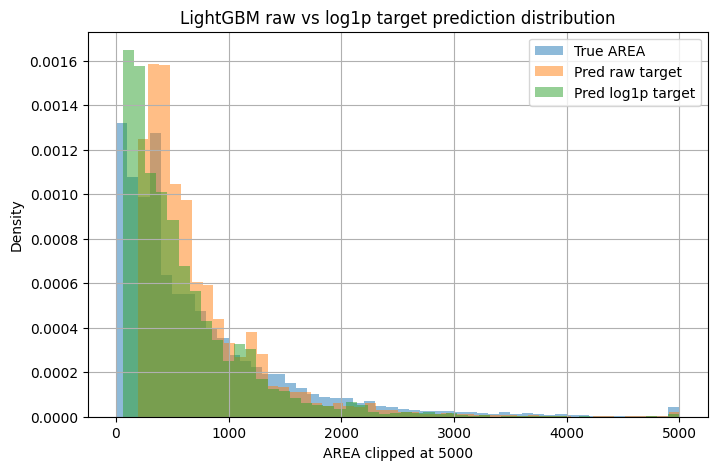

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

pred_compare_df["y_true"].clip(upper=5000).hist(
    bins=50,
    alpha=0.5,
    label="True AREA",
    density=True
)

pred_compare_df["pred_raw"].clip(upper=5000).hist(
    bins=50,
    alpha=0.5,
    label="Pred raw target",
    density=True
)

pred_compare_df["pred_log1p"].clip(upper=5000).hist(
    bins=50,
    alpha=0.5,
    label="Pred log1p target",
    density=True
)

plt.xlabel("AREA clipped at 5000")
plt.ylabel("Density")
plt.title("LightGBM raw vs log1p target prediction distribution")
plt.legend()
plt.show()

### 3-4. AREA_final 생성

최종 light_gbm + log1p로 생성

In [19]:
# ============================================================
# 0. 기본 확인
# ============================================================

required_cols = [
    "FARM_UNIQUE_NO",
    "C2023_imp", "C2024_imp", "C2025_imp",
    "AREA_max",
    "n_area_rows", "multi_area_row_flag", "scale_info_missing"
]

missing_cols = [col for col in required_cols if col not in area_imp.columns]

if missing_cols:
    raise ValueError(f"area_imp에 필요한 컬럼이 없습니다: {missing_cols}")

print("area_imp shape:", area_imp.shape)
print("FARM_UNIQUE_NO 중복:", area_imp.duplicated("FARM_UNIQUE_NO").sum())

area_imp shape: (86703, 24)
FARM_UNIQUE_NO 중복: 0


In [22]:
# ============================================================
# 1. 사육규모 파생변수 생성
# ============================================================

imp_count_cols = ["C2023_imp", "C2024_imp", "C2025_imp"]

area_imp["scale_avg"] = area_imp[imp_count_cols].mean(axis=1)
area_imp["scale_max"] = area_imp[imp_count_cols].max(axis=1)
area_imp["scale_min"] = area_imp[imp_count_cols].min(axis=1)
area_imp["scale_std"] = area_imp[imp_count_cols].std(axis=1)
area_imp["scale_range"] = area_imp["scale_max"] - area_imp["scale_min"]

area_imp["scale_change_23_25"] = (
    area_imp["C2025_imp"] - area_imp["C2023_imp"]
)

area_imp["scale_growth_23_25"] = (
    area_imp["scale_change_23_25"]
    / area_imp["C2023_imp"].replace(0, np.nan)
)

area_imp["scale_growth_23_25"] = (
    area_imp["scale_growth_23_25"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

print("사육규모 파생변수 생성 완료")
display(
    area_imp[
        [
            "C2023_imp", "C2024_imp", "C2025_imp",
            "scale_avg", "scale_max", "scale_min", "scale_std",
            "scale_range", "scale_change_23_25", "scale_growth_23_25"
        ]
    ].head()
)

사육규모 파생변수 생성 완료


,C2023_imp,C2024_imp,C2025_imp,scale_avg,scale_max,scale_min,scale_std,scale_range,scale_change_23_25,scale_growth_23_25
0,69.0,55.0,37.0,53.666667,69.0,37.0,16.041613,32.0,-32.0,-0.463768
1,9.0,8.0,6.0,7.666667,9.0,6.0,1.527525,3.0,-3.0,-0.333333
2,8.0,8.0,8.0,8.000000,8.0,8.0,0.000000,0.0,0.0,0.000000
3,126.0,132.0,134.0,130.666667,134.0,126.0,4.163332,8.0,8.0,0.063492
4,6.0,9.0,6.0,7.000000,9.0,6.0,1.732051,3.0,0.0,0.000000


In [23]:
# ============================================================
# 2. AREA 기준값 설정
# ============================================================
# AREA_max를 최종 AREA 결측 대체 target으로 사용

area_imp["AREA_base"] = area_imp["AREA_max"]

# AREA가 원래 결측이었는지 기록
# 이 flag는 AREA imputation 모델에는 넣지 않고, 최종 train merge 후 보조 변수로 사용
area_imp["area_missing"] = area_imp["AREA_base"].isna().astype(int)

print("AREA_base 관측 수:", area_imp["AREA_base"].notna().sum())
print("AREA_base 결측 수:", area_imp["AREA_base"].isna().sum())
print("AREA 결측률:", area_imp["AREA_base"].isna().mean())

AREA_base 관측 수: 59549
AREA_base 결측 수: 27154
AREA 결측률: 0.31318408820917387


In [24]:
# ============================================================
# 3. LightGBM + log1p AREA imputation용 feature 설정
# ============================================================

area_model_features = [
    "C2023_imp", "C2024_imp", "C2025_imp",
    "scale_avg", "scale_max", "scale_min", "scale_std",
    "scale_range", "scale_change_23_25", "scale_growth_23_25",
    "n_area_rows", "multi_area_row_flag", "scale_info_missing"
]

# feature 결측 확인
print("AREA 모델 feature 결측 개수:")
display(area_imp[area_model_features].isna().sum())

# target 관측 데이터
model_df = area_imp[area_imp["AREA_base"].notna()].copy()

# AREA가 음수인 경우 제거
model_df = model_df[model_df["AREA_base"] >= 0].copy()

X = model_df[area_model_features].copy()
y = model_df["AREA_base"].copy()

print("LightGBM 학습용 데이터 shape:", model_df.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)

AREA 모델 feature 결측 개수:


,0
C2023_imp,0
C2024_imp,0
C2025_imp,0
scale_avg,0
scale_max,0
scale_min,0
scale_std,0
scale_range,0
scale_change_23_25,0
scale_growth_23_25,0


LightGBM 학습용 데이터 shape: (59549, 24)
X shape: (59549, 13)
y shape: (59549,)


In [25]:
# ============================================================
# 4. Hold-out validation으로 LightGBM + log1p 성능 확인
# ============================================================

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 핵심: log1p target 사용
y_train_log = np.log1p(y_train)

lgbm_valid_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LGBMRegressor(
        n_estimators=600,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="regression",
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

lgbm_valid_model.fit(X_train, y_train_log)

# log scale 예측
valid_pred_log = lgbm_valid_model.predict(X_valid)

# 원래 AREA scale로 복원
valid_pred = np.expm1(valid_pred_log)
valid_pred = np.clip(valid_pred, a_min=0, a_max=None)

mae = mean_absolute_error(y_valid, valid_pred)
rmse = np.sqrt(mean_squared_error(y_valid, valid_pred))
medae = median_absolute_error(y_valid, valid_pred)
r2 = r2_score(y_valid, valid_pred)

print("[LightGBM + log1p AREA imputation validation]")
print(f"MAE   : {mae:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"MedAE : {medae:.4f}")
print(f"R2    : {r2:.4f}")

[LightGBM + log1p AREA imputation validation]
MAE   : 320.6393
RMSE  : 745.0462
MedAE : 156.8415
R2    : 0.3814


In [26]:
# ============================================================
# 5. 전체 관측 AREA로 최종 LightGBM + log1p 학습
# ============================================================

X_train_final = model_df[area_model_features].copy()
y_train_final_log = np.log1p(model_df["AREA_base"])

final_area_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LGBMRegressor(
        n_estimators=600,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="regression",
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

final_area_model.fit(X_train_final, y_train_final_log)

print("최종 LightGBM + log1p AREA imputation model 학습 완료")

최종 LightGBM + log1p AREA imputation model 학습 완료


In [27]:
# ============================================================
# 6. AREA 결측 대체
# ============================================================

# 관측값은 그대로 유지
area_imp["AREA_final"] = area_imp["AREA_base"]

missing_area_mask = area_imp["AREA_final"].isna()

print("대체 전 AREA_final 결측 수:", missing_area_mask.sum())

# 결측 AREA 예측
X_missing = area_imp.loc[missing_area_mask, area_model_features].copy()

pred_area_log = final_area_model.predict(X_missing)

# log1p 예측값을 원래 AREA scale로 복원
pred_area = np.expm1(pred_area_log)
pred_area = np.clip(pred_area, a_min=0, a_max=None)

area_imp.loc[missing_area_mask, "AREA_final"] = pred_area

area_imp["AREA_impute_method"] = np.where(
    area_imp["area_missing"] == 1,
    "lightgbm_log1p_imputed",
    "observed"
)

print("대체 후 AREA_final 결측 수:", area_imp["AREA_final"].isna().sum())
print(area_imp["AREA_impute_method"].value_counts())

대체 전 AREA_final 결측 수: 27154
대체 후 AREA_final 결측 수: 0
AREA_impute_method
observed                  59549
lightgbm_log1p_imputed    27154
Name: count, dtype: int64


In [28]:
# ============================================================
# 7. AREA 대체값 분포 확인
# ============================================================

print("[AREA_final 요약]")
display(area_imp["AREA_final"].describe())

print("[observed vs imputed AREA 비교]")
display(
    area_imp
    .groupby("AREA_impute_method")["AREA_final"]
    .describe()
)

[AREA_final 요약]


,AREA_final
count,86703.000000
mean,707.223647
std,865.934412
min,0.000000
25%,195.000000
50%,433.200000
75%,923.817102
max,48360.000000


[observed vs imputed AREA 비교]


,count,mean,std,min,25%,50%,75%,max
AREA_impute_method,,,,,,,,
lightgbm_log1p_imputed,27154.0,627.785202,721.884328,61.742227,185.858217,394.64219,824.890214,13698.83722
observed,59549.0,743.447118,921.933095,0.000000,210.000000,452.00000,967.710000,48360.00000


------

In [30]:
# ============================================================
# 8. 면적 기반 파생변수 생성
# ============================================================

area_imp["head_per_area"] = (
    area_imp["scale_avg"]
    / area_imp["AREA_final"].replace(0, np.nan)
)

area_imp["area_per_head"] = (
    area_imp["AREA_final"]
    / area_imp["scale_avg"].replace(0, np.nan)
)

for col in ["head_per_area", "area_per_head"]:
    area_imp[col] = (
        area_imp[col]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(area_imp[col].median())
    )

print("면적 기반 파생변수 생성 완료")
display(
    area_imp[
        [
            "FARM_UNIQUE_NO",
            "scale_avg", "AREA_final",
            "head_per_area", "area_per_head",
            "area_missing", "AREA_impute_method"
        ]
    ].head()
)

면적 기반 파생변수 생성 완료


,FARM_UNIQUE_NO,scale_avg,AREA_final,head_per_area,area_per_head,area_missing,AREA_impute_method
0,++3dDT9h9GLLBVoQDgn1IA==,53.666667,1056.000000,0.050821,19.677019,0,observed
1,++9y4LAgYZMHjJNqlquqOA==,7.666667,90.000000,0.085185,11.739130,0,observed
2,++BS1viAh3hOdGNLUqO9AQ==,8.000000,256.253484,0.031219,32.031686,1,lightgbm_log1p_imputed
3,++EgHgT0FBhXP2UY4tsA2Q==,130.666667,1040.000000,0.125641,7.959184,0,observed
4,++FegxXsnx/IotYuAWBj8g==,7.000000,368.340000,0.019004,52.620000,0,observed


In [31]:
# ============================================================
# 9. 최종 area_final 생성
# ============================================================

area_final = area_imp[
    [
        "FARM_UNIQUE_NO",

        # 사육두수 보간값
        "C2023_imp", "C2024_imp", "C2025_imp",

        # 사육규모 파생변수
        "scale_avg", "scale_max", "scale_min", "scale_std",
        "scale_range", "scale_change_23_25", "scale_growth_23_25",

        # AREA 최종값
        "AREA_final",

        # 면적 기반 파생변수
        "head_per_area", "area_per_head",

        # 최소 flag
        "n_area_rows", "multi_area_row_flag",
        "area_missing", "scale_info_missing",

        # 추적용
        "AREA_impute_method"
    ]
].copy()

print("area_final shape:", area_final.shape)
print("FARM_UNIQUE_NO 중복:", area_final.duplicated("FARM_UNIQUE_NO").sum())
print("결측 개수:")
display(area_final.isna().sum())

display(area_final.head())

area_final shape: (86703, 19)
FARM_UNIQUE_NO 중복: 0
결측 개수:


,0
FARM_UNIQUE_NO,0
C2023_imp,0
C2024_imp,0
C2025_imp,0
scale_avg,0
scale_max,0
scale_min,0
scale_std,0
scale_range,0
scale_change_23_25,0


,FARM_UNIQUE_NO,C2023_imp,C2024_imp,C2025_imp,scale_avg,scale_max,scale_min,scale_std,scale_range,scale_change_23_25,scale_growth_23_25,AREA_final,head_per_area,area_per_head,n_area_rows,multi_area_row_flag,area_missing,scale_info_missing,AREA_impute_method
0,++3dDT9h9GLLBVoQDgn1IA==,69.0,55.0,37.0,53.666667,69.0,37.0,16.041613,32.0,-32.0,-0.463768,1056.000000,0.050821,19.677019,1,0,0,0,observed
1,++9y4LAgYZMHjJNqlquqOA==,9.0,8.0,6.0,7.666667,9.0,6.0,1.527525,3.0,-3.0,-0.333333,90.000000,0.085185,11.739130,1,0,0,0,observed
2,++BS1viAh3hOdGNLUqO9AQ==,8.0,8.0,8.0,8.000000,8.0,8.0,0.000000,0.0,0.0,0.000000,256.253484,0.031219,32.031686,1,0,1,1,lightgbm_log1p_imputed
3,++EgHgT0FBhXP2UY4tsA2Q==,126.0,132.0,134.0,130.666667,134.0,126.0,4.163332,8.0,8.0,0.063492,1040.000000,0.125641,7.959184,1,0,0,0,observed
4,++FegxXsnx/IotYuAWBj8g==,6.0,9.0,6.0,7.000000,9.0,6.0,1.732051,3.0,0.0,0.000000,368.340000,0.019004,52.620000,1,0,0,0,observed


### 결측치 처리 분포 확인/시각화

In [32]:
# ============================================================
# 2. observed / imputed 요약통계
# ============================================================

area_summary = (
    area_imp
    .assign(area_group=np.where(area_imp["area_missing"] == 1, "imputed", "observed"))
    .groupby("area_group")["AREA_final"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99])
)

display(area_summary)

,count,mean,std,min,1%,5%,25%,50%,75%,90%,95%,99%,max
area_group,,,,,,,,,,,,,
imputed,27154.0,627.785202,721.884328,61.742227,81.965665,106.179855,185.858217,394.64219,824.890214,1371.971513,1871.067594,3233.230412,13698.83722
observed,59549.0,743.447118,921.933095,0.000000,25.200000,50.000000,210.000000,452.00000,967.710000,1692.000000,2292.840000,3902.246400,48360.00000


In [33]:
# ============================================================
# 3. scale_avg 구간별 observed / imputed AREA 비교
# ============================================================

area_check = area_imp.copy()

area_check["scale_bin"] = pd.qcut(
    area_check["scale_avg"],
    q=10,
    duplicates="drop"
)

bin_compare = (
    area_check
    .assign(area_group=np.where(area_check["area_missing"] == 1, "imputed", "observed"))
    .groupby(["scale_bin", "area_group"], observed=True)["AREA_final"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.90])
    .reset_index()
)

display(bin_compare)

,scale_bin,area_group,count,mean,std,min,25%,50%,75%,90%,max
0,"(0.999, 3.0]",imputed,4725.0,144.465640,57.555842,61.742227,107.760284,148.405562,161.123088,185.858217,1432.499355
1,"(0.999, 3.0]",observed,5512.0,381.354365,726.355926,0.000000,47.300000,99.000000,330.000000,1115.650000,10055.800000
2,"(3.0, 5.0]",imputed,2601.0,160.793769,63.997074,92.578836,117.390166,157.979909,185.928274,216.305988,1152.617041
3,"(3.0, 5.0]",observed,4581.0,294.702689,524.999182,12.000000,65.000000,132.000000,300.000000,627.120000,7069.260000
4,"(5.0, 8.667]",imputed,2812.0,219.080706,99.970216,117.615619,155.337388,206.631613,250.473508,311.518437,1688.404466
5,"(5.0, 8.667]",observed,6228.0,345.769597,630.592499,0.000000,96.000000,189.000000,349.000000,696.001000,24514.000000
6,"(8.667, 13.333]",imputed,2265.0,307.221943,105.426221,172.401497,236.800925,280.940549,365.342361,419.053356,1229.175554
7,"(8.667, 13.333]",observed,6109.0,401.128726,495.706229,26.500000,160.000000,270.000000,420.000000,798.760000,8064.000000
8,"(13.333, 20.0]",imputed,2242.0,406.162650,127.981497,237.311408,321.190466,383.855756,454.357250,573.999286,1192.277462
9,"(13.333, 20.0]",observed,6474.0,477.847748,529.016545,8.100000,226.750000,343.760000,532.042500,910.032000,11696.000000


In [34]:
# ============================================================
# 4. observed AREA 극단값 확인
# ============================================================

display(
    area_imp.loc[
        area_imp["area_missing"] == 0,
        [
            "FARM_UNIQUE_NO",
            "C2023_imp", "C2024_imp", "C2025_imp",
            "scale_avg",
            "AREA_final",
            "head_per_area",
            "area_per_head",
            "n_area_rows",
            "multi_area_row_flag"
        ]
    ]
    .sort_values("AREA_final", ascending=False)
    .head(15)
)

,FARM_UNIQUE_NO,C2023_imp,C2024_imp,C2025_imp,scale_avg,AREA_final,head_per_area,area_per_head,n_area_rows,multi_area_row_flag
32400,Lp2yGctcCAmr2+yVMrvlnQ==,115.0,122.0,102.0,113.000000,48360.00,0.002337,427.964602,1,0
41063,SJoxan53bgok5ouL94p7Og==,2557.0,2153.0,2103.0,2271.000000,38692.00,0.058694,17.037428,1,0
69620,nLhPZkF2Q0JUW8QgkmPp+g==,651.0,1032.0,903.0,862.000000,25568.40,0.033713,29.661717,1,0
79905,uz8mEJShF8dt88bGsyiAuA==,8.0,5.0,5.0,6.000000,24514.00,0.000245,4085.666667,1,0
65283,k7wKtWeb/Oq7wBfveQ23xw==,253.0,253.0,253.0,253.000000,22441.06,0.011274,88.699842,1,0
13674,8/Cxw0h17o/17KmKd1hVvQ==,1.0,393.0,485.0,293.000000,20884.38,0.014030,71.277747,1,0
41557,Sg8VxKLf9U9cto0v9cX0Cg==,46.0,38.0,29.0,37.666667,20165.00,0.001868,535.353982,1,0
4589,1IcCixYxvFZCpH8WO8MoIg==,101.0,99.0,82.0,94.000000,18877.20,0.004980,200.821277,1,0
6735,2soP9Vi4meJn1DOismMGIw==,228.0,228.0,228.0,228.000000,17698.24,0.012883,77.623860,1,0
61606,hU8a3ujznOjBzgil3dv2Mg==,1468.0,1283.0,1423.0,1391.333333,17231.60,0.080743,12.384954,1,0


In [35]:
# ============================================================
# 5. imputed AREA 극단값 확인
# ============================================================

display(
    area_final.loc[
        area_final["area_missing"] == 1,
        [
            "FARM_UNIQUE_NO",
            "C2023_imp", "C2024_imp", "C2025_imp",
            "scale_avg",
            "AREA_final",
            "head_per_area",
            "area_per_head",
            "n_area_rows",
            "multi_area_row_flag",
            "AREA_impute_method"
        ]
    ]
    .sort_values("AREA_final", ascending=False)
    .head(30)
)

,FARM_UNIQUE_NO,C2023_imp,C2024_imp,C2025_imp,scale_avg,AREA_final,head_per_area,area_per_head,n_area_rows,multi_area_row_flag,AREA_impute_method
86565,zski6ygbED4cUlH76spkGA==,651.0,605.0,928.0,728.000000,13698.837220,0.053143,18.817084,1,0,lightgbm_log1p_imputed
11942,6gi6AXa8xcxe6zrMgWRsKQ==,841.0,870.0,1259.0,990.000000,13613.573229,0.072722,13.751084,1,0,lightgbm_log1p_imputed
67441,liPUL8IRbCsubW/Bf9gYBA==,1583.0,1215.0,1471.0,1423.000000,13410.733197,0.106109,9.424268,1,0,lightgbm_log1p_imputed
25628,GmfQkIKlt2fGAvFzjVOSWA==,1213.0,565.0,781.0,853.000000,11988.128023,0.071154,14.054077,1,0,lightgbm_log1p_imputed
4854,1VDxNeT7NylUjqUgVOTJnw==,542.0,814.0,495.0,617.000000,10739.842579,0.057450,17.406552,1,0,lightgbm_log1p_imputed
52615,arHm1+NFLQOoAjso3nTTSg==,856.0,574.0,422.0,617.333333,10228.932907,0.060352,16.569546,1,0,lightgbm_log1p_imputed
73108,pzWr2ynDKHoE8qG0xK93/A==,993.0,840.0,808.0,880.333333,10195.960671,0.086341,11.581932,1,0,lightgbm_log1p_imputed
17890,B1KUSF2+Ux0JNW0zzAww+w==,821.0,637.0,363.0,607.000000,9765.281418,0.062159,16.087778,1,0,lightgbm_log1p_imputed
37859,Pw3vVRIoJ4lVZsjYwKfo/A==,1134.0,913.0,1041.0,1029.333333,9658.754358,0.106570,9.383505,1,0,lightgbm_log1p_imputed
56752,dsOYXO/lBAgYTefdDzETxA==,2829.0,2765.0,2603.0,2732.333333,9620.785736,0.284003,3.521088,1,0,lightgbm_log1p_imputed


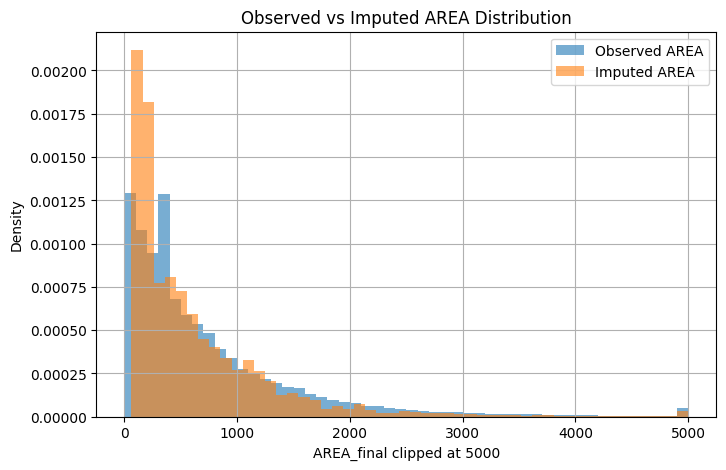

In [36]:
# Observed vs Imputed AREA 분포
plt.figure(figsize=(8, 5))

area_final.loc[
    area_final["area_missing"] == 0,
    "AREA_final"
].clip(upper=5000).hist(
    bins=50,
    alpha=0.6,
    label="Observed AREA",
    density=True
)

area_final.loc[
    area_final["area_missing"] == 1,
    "AREA_final"
].clip(upper=5000).hist(
    bins=50,
    alpha=0.6,
    label="Imputed AREA",
    density=True
)

plt.xlabel("AREA_final clipped at 5000")
plt.ylabel("Density")
plt.legend()
plt.title("Observed vs Imputed AREA Distribution")
plt.show()

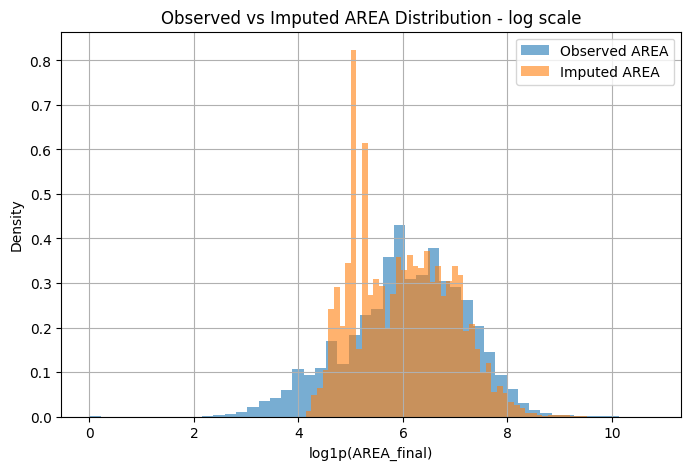

In [37]:
# log-scale 분포
plt.figure(figsize=(8, 5))

np.log1p(
    area_final.loc[area_final["area_missing"] == 0, "AREA_final"]
).hist(
    bins=50,
    alpha=0.6,
    label="Observed AREA",
    density=True
)

np.log1p(
    area_final.loc[area_final["area_missing"] == 1, "AREA_final"]
).hist(
    bins=50,
    alpha=0.6,
    label="Imputed AREA",
    density=True
)

plt.xlabel("log1p(AREA_final)")
plt.ylabel("Density")
plt.legend()
plt.title("Observed vs Imputed AREA Distribution - log scale")
plt.show()

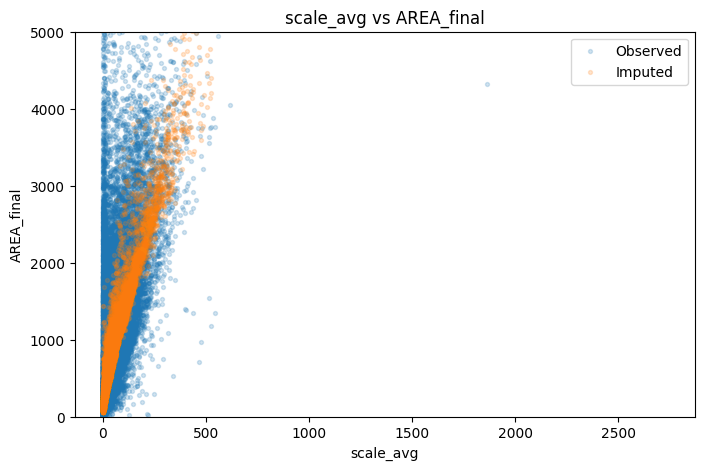

In [38]:
# scale_Avg vs area_final
plt.figure(figsize=(8, 5))

obs = area_final["area_missing"] == 0
imp = area_final["area_missing"] == 1

plt.scatter(
    area_final.loc[obs, "scale_avg"],
    area_final.loc[obs, "AREA_final"],
    alpha=0.2,
    s=8,
    label="Observed"
)

plt.scatter(
    area_final.loc[imp, "scale_avg"],
    area_final.loc[imp, "AREA_final"],
    alpha=0.2,
    s=8,
    label="Imputed"
)

plt.xlabel("scale_avg")
plt.ylabel("AREA_final")
plt.title("scale_avg vs AREA_final")
plt.ylim(0, 5000)
plt.legend()
plt.show()

area_group,imputed,observed
scale_bin,,
"(0.999, 3.0]",148.405562,99.000
"(3.0, 5.0]",157.979909,132.000
"(5.0, 8.667]",206.631613,189.000
"(8.667, 13.333]",280.940549,270.000
"(13.333, 20.0]",383.855756,343.760
"(20.0, 28.667]",476.447980,415.905
"(28.667, 41.0]",589.998885,552.900
"(41.0, 60.0]",791.575867,759.000
"(60.0, 96.0]",1105.959730,1080.000


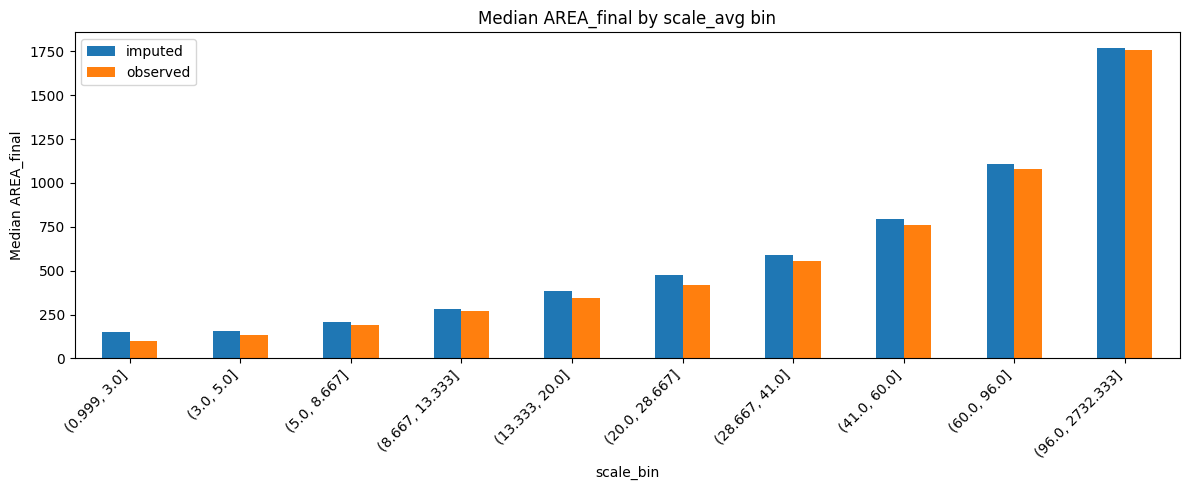

In [59]:
# scale_bin별 median 비교
median_compare = (
    area_check
    .assign(area_group=np.where(area_check["area_missing"] == 1, "imputed", "observed"))
    .groupby(["scale_bin", "area_group"], observed=True)["AREA_final"]
    .median()
    .reset_index()
)

median_pivot = median_compare.pivot(
    index="scale_bin",
    columns="area_group",
    values="AREA_final"
)

display(median_pivot)

median_pivot.plot(kind="bar", figsize=(12, 5))
plt.ylabel("Median AREA_final")
plt.title("Median AREA_final by scale_avg bin")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

### 최종 저장

In [49]:
# ============================================================
# 10. 최종 저장용 컬럼명 정리: C2023_imp → C2023
# ============================================================

area_final_clean = area_final.rename(columns={
    "C2023_imp": "C2023",
    "C2024_imp": "C2024",
    "C2025_imp": "C2025"
}).copy()

# 최소 저장 컬럼
keep_cols = [
    "FARM_UNIQUE_NO",
    "C2023", "C2024", "C2025",
    "scale_avg",
    "scale_change_23_25",
    "AREA_final",
    "area_per_head",
    "n_area_rows",
    "area_missing",
    "scale_info_missing"
]

area_final_min = area_final_clean[keep_cols].copy()

print("area_final_min shape:", area_final_min.shape)
print("FARM_UNIQUE_NO 중복:", area_final_min.duplicated("FARM_UNIQUE_NO").sum())
display(area_final_min.head())
display(area_final_min.isna().sum())

area_final_min shape: (86703, 11)
FARM_UNIQUE_NO 중복: 0


,FARM_UNIQUE_NO,C2023,C2024,C2025,scale_avg,scale_change_23_25,AREA_final,area_per_head,n_area_rows,area_missing,scale_info_missing
0,++3dDT9h9GLLBVoQDgn1IA==,69.0,55.0,37.0,53.666667,-32.0,1056.000000,19.677019,1,0,0
1,++9y4LAgYZMHjJNqlquqOA==,9.0,8.0,6.0,7.666667,-3.0,90.000000,11.739130,1,0,0
2,++BS1viAh3hOdGNLUqO9AQ==,8.0,8.0,8.0,8.000000,0.0,256.253484,32.031686,1,1,1
3,++EgHgT0FBhXP2UY4tsA2Q==,126.0,132.0,134.0,130.666667,8.0,1040.000000,7.959184,1,0,0
4,++FegxXsnx/IotYuAWBj8g==,6.0,9.0,6.0,7.000000,0.0,368.340000,52.620000,1,0,0


,0
FARM_UNIQUE_NO,0
C2023,0
C2024,0
C2025,0
scale_avg,0
scale_change_23_25,0
AREA_final,0
area_per_head,0
n_area_rows,0
area_missing,0


In [50]:
# ============================================================
# 11. area_final.csv 저장
# ============================================================

area_final_min.to_csv(
    "area_final.csv",
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료: area_final.csv")
print("저장 shape:", area_final_min.shape)

저장 완료: area_final.csv
저장 shape: (86703, 11)


In [51]:
from google.colab import files
files.download("area_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>